# Schematic map of Campi Flegrei

Very simple map: coastline only (no topography), one station triangle (CPOZ)
and one circle per event of the catalogue.

Events commented out in the `.pf` catalogue (lines starting with `#`) are skipped.
Run from inside `codes/` (all paths are relative to it).


In [71]:
import os

import pygmt

In [72]:
# ============================================================
#  USER SETTINGS
# ============================================================
workdir = '../'

catdir = os.path.join(workdir, 'CAT')
metadatadir = os.path.join(workdir, 'META_DATA')
plotdir = os.path.join(workdir, 'PLOTS', 'MAPS')
os.makedirs(plotdir, exist_ok=True)

catname = os.path.join(catdir, 'catalogue_flegrei_VLP.pf')              # CHANGE
staname = os.path.join(metadatadir, 'stations_flegrei_INGV_final.pf')
STATION_CODE = 'CPOZ'                                                   # CHANGE

plot_filename = os.path.join(plotdir, 'schematic_map_CPOZ_VT.pdf')

# --- map area --------------------------------------------------------
minlon, maxlon = 14.07, 14.175
minlat, maxlat = 40.775, 40.85
MAP_WIDTH = '12c'          # map width (drives the whole layout)

# --- background ------------------------------------------------------
LAND_COLOR    = '#D6D6D6'    # swap LAND/WATER to invert the schematic look
WATER_COLOR   = '#FFFFFF'
SHORELINE_PEN = '0.8p,black'
FRAME_PEN     = '0.8p,black'

# --- events ----------------------------------------------------------
EV_COLOR = "#868686"
EV_SIZE  = '0.7c'         # circle diameter, same for every event
EV_PEN   = '0.5p,black'            # e.g. '0.5p,white' to separate overlapping circles 

# --- station ---------------------------------------------------------
STA_COLOR = '#515151'
STA_SIZE  = '2.0c'         # triangle size
STA_PEN   = '0.8p,black'           # e.g. '0.8p,black' for a border
SHOW_STA_NAME = True

SHOW_SCALE = False         # small scale bar in the bottom-left corner

In [73]:
def load_events_pf(fname):
    """Events of a pyrocko .pf catalogue, skipping the commented (#) ones.

    Returns a list of dicts, one per event, with the raw 'key = value' fields.
    """
    events, event = [], {}
    for line in open(fname):
        line = line.strip()
        if not line or line.startswith('#'):     # commented event -> skipped
            continue
        if line.startswith('---'):               # end of one event block
            if event:
                events.append(event)
            event = {}
            continue
        if '=' in line:
            key, value = line.split('=', 1)
            event[key.strip()] = value.strip()
    if event:                                    # last block has no separator
        events.append(event)
    return events


def load_station_pf(fname, code):
    """(lat, lon) of one station of a pyrocko station file."""
    for line in open(fname):
        if line.startswith((' ', '\t', '#')) or not line.strip():
            continue                             # channel lines are indented
        fields = line.split()
        if code in fields[0].split('.'):
            return float(fields[1]), float(fields[2])
    raise ValueError(f'station {code} not found in {fname}')

In [74]:
events = load_events_pf(catname)
ev_lats = [float(ev['latitude']) for ev in events]
ev_lons = [float(ev['longitude']) for ev in events]

sta_lat, sta_lon = load_station_pf(staname, STATION_CODE)

print(f'Catalogue: {catname}')
print('Events plotted:', len(events))
print(f'Station {STATION_CODE}: {sta_lat}, {sta_lon}')

Catalogue: ../CAT/catalogue_flegrei_VLP.pf
Events plotted: 19
Station CPOZ: 40.821072, 14.11911


saved: ../PLOTS/MAPS/schematic_map_CPOZ_VT.pdf


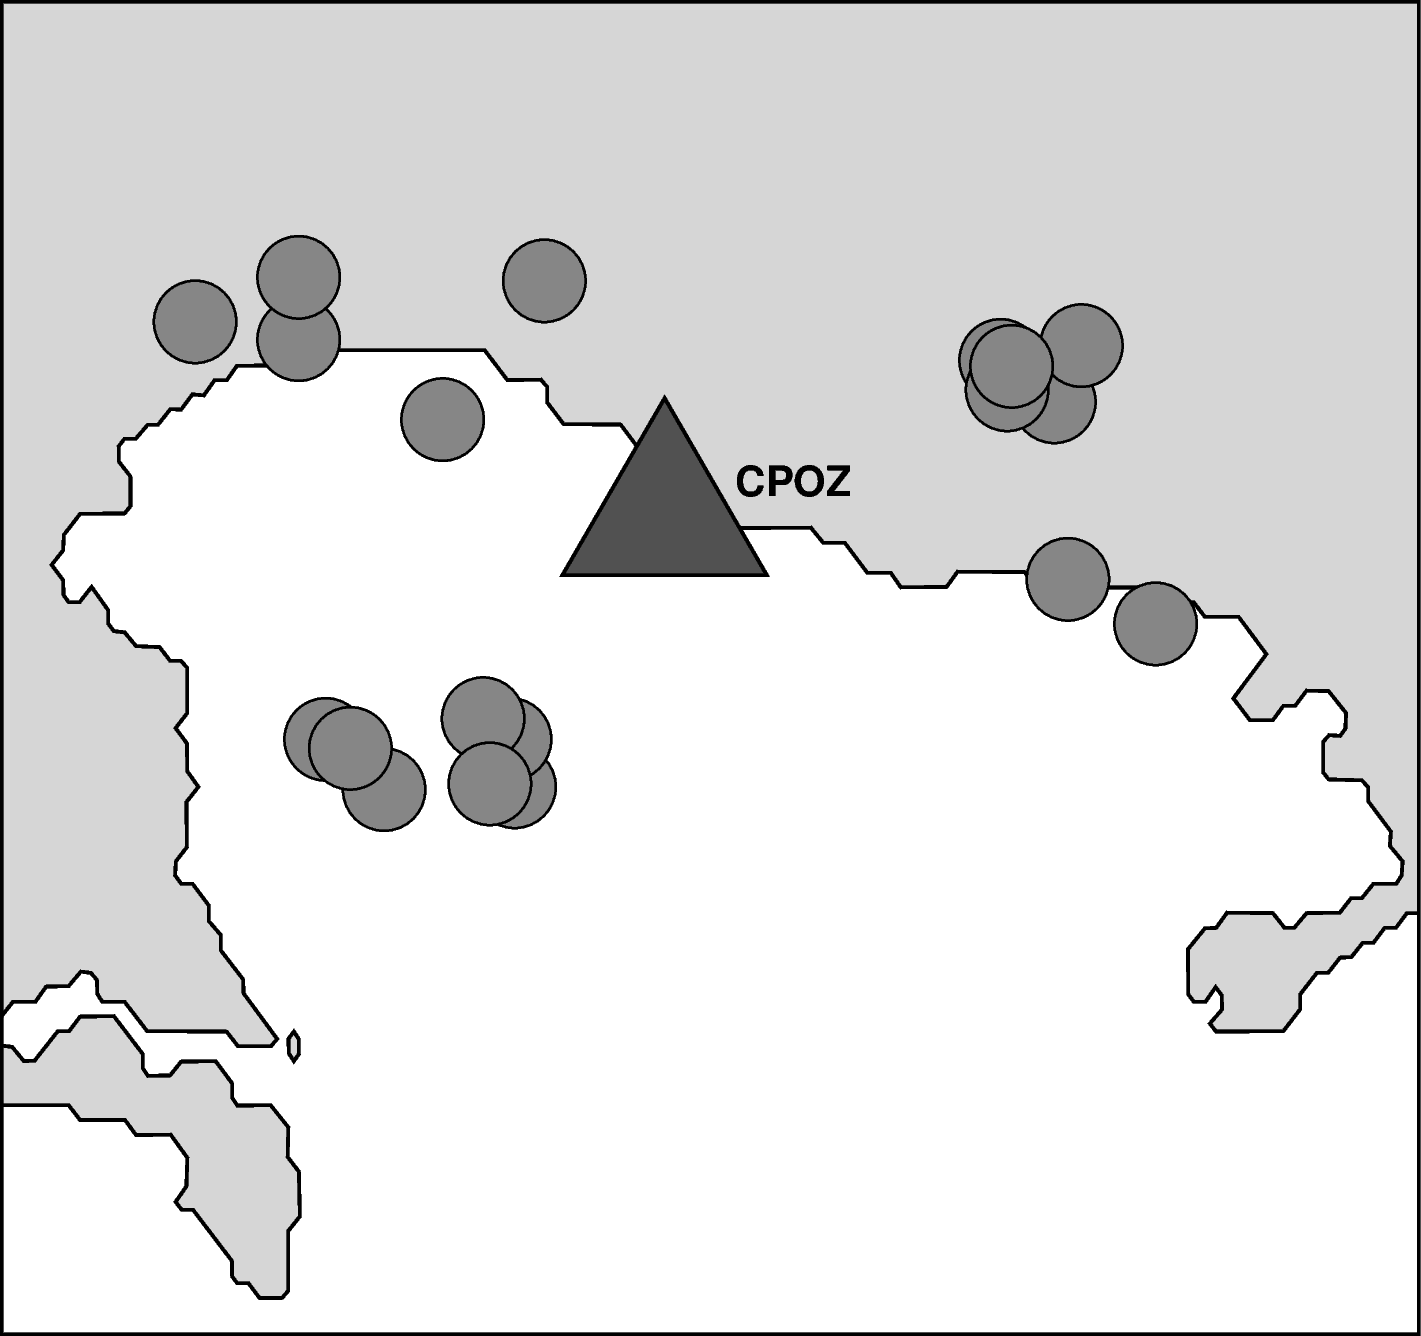

In [75]:
fig = pygmt.Figure()
pygmt.config(MAP_FRAME_TYPE='plain', MAP_FRAME_PEN=FRAME_PEN)

# coastline: plain box, no annotations, no ticks (lowercase 'wsen')
fig.coast(
    region=[minlon, maxlon, minlat, maxlat],
    projection='M' + MAP_WIDTH,
    frame=['wsen'],
    land=LAND_COLOR,
    water=WATER_COLOR,
    shorelines=SHORELINE_PEN,
    resolution='f',            # full resolution, needed at this scale
)

# events
fig.plot(x=ev_lons, y=ev_lats, style='c' + EV_SIZE, fill=EV_COLOR, pen=EV_PEN)

# station
fig.plot(x=[sta_lon], y=[sta_lat], style='t' + STA_SIZE, fill=STA_COLOR, pen=STA_PEN)
if SHOW_STA_NAME:
    fig.text(x=sta_lon, y=sta_lat, text=STATION_CODE,
             font='10p,Helvetica-Bold,black', justify='LM', offset='0.6c/0.3c')

if SHOW_SCALE:
    fig.basemap(map_scale='jBL+w1k+o0.5c/0.5c+f')

fig.savefig(plot_filename)
#fig.savefig(plot_filename.replace('.pdf', '.png'), dpi=300)
print('saved:', plot_filename)

fig.show()